In [1]:
#-- IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#--READ FILE
df = pd.read_csv(r"C:\Users\priya\OneDrive\Documents\ecommerce_transactions.csv")
df.head()

,Transaction_ID,User_Name,Age,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,14-04-2023
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,30-07-2023
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,17-09-2023
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,21-06-2023
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,29-10-2024


In [6]:
#-- CHECK THE DATASET
df.shape

(50000, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    50000 non-null  int64  
 1   User_Name         50000 non-null  object 
 2   Age               50000 non-null  int64  
 3   Country           50000 non-null  object 
 4   Product_Category  50000 non-null  object 
 5   Purchase_Amount   50000 non-null  float64
 6   Payment_Method    50000 non-null  object 
 7   Transaction_Date  50000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.1+ MB


In [8]:
df.describe()

,Transaction_ID,Age,Purchase_Amount
count,50000.000000,50000.000000,50000.000000
mean,25000.500000,43.968680,503.159793
std,14433.901067,15.260578,286.563558
min,1.000000,18.000000,5.040000
25%,12500.750000,31.000000,255.450000
50%,25000.500000,44.000000,503.110000
75%,37500.250000,57.000000,751.162500
max,50000.000000,70.000000,999.980000


In [9]:
#--CHECK MISSING VALUES

df.isnull().sum()

Transaction_ID      0
User_Name           0
Age                 0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

In [11]:
#--CONVERT THE DATE

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

In [12]:
#--CHECK DUPLICATE TRANSATIONS

df.duplicated().sum()

np.int64(0)

In [13]:
#-- HANDLE MISSING VALUES

df.isnull().sum()

Transaction_ID      0
User_Name           0
Age                 0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

In [14]:
df = df.dropna()

In [15]:
#--CHECK DATA TYPES

df.dtypes

Transaction_ID               int64
User_Name                   object
Age                          int64
Country                     object
Product_Category            object
Purchase_Amount            float64
Payment_Method              object
Transaction_Date    datetime64[ns]
dtype: object

In [16]:
#--CHECK FOR DUPLICATES

df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()

In [18]:
#--- EDA

total_revenue = df['Purchase_Amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 25157989.65


In [19]:
#--AVERAGE PURCHASE

average_purchase = df['Purchase_Amount'].mean()

print("Average Purchase Amount:", average_purchase)

Average Purchase Amount: 503.159793


In [20]:
#--MINIMUM AND MAXIMUM PURCHASE

print("Minimum Purchase:", df['Purchase_Amount'].min())
print("Maximum Purchase:", df['Purchase_Amount'].max())

Minimum Purchase: 5.04
Maximum Purchase: 999.98


In [21]:
#-- NUMBER OF TRANSACTION

print("Total Transactions:", df['Transaction_ID'].nunique())

Total Transactions: 50000


In [22]:
#--- TOP CUSTOMER

top_customers = (
    df.groupby('User_Name')['Purchase_Amount']
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)

User_Name
Sophia Harris    296354.98
James Allen      278079.15
Olivia Hall      277302.09
Isabella Hall    275798.04
Noah Anderson    274347.15
Emma Clark       274313.60
Ava Clark        273776.79
Elijah Hall      271861.61
James Lewis      271007.68
Ava Hall         268756.73
Name: Purchase_Amount, dtype: float64

In [27]:
#-- TOP 10 CUSTOMER CHART

# Check that the required columns exist
print("Columns in dataset:")
print(df.columns.tolist())

# Create customer spending summary
top_customers = (
    df.groupby('User_Name')['Purchase_Amount']
      .sum()
      .sort_values(ascending=False)
)

# Select top 10 customers
top_10_customers = top_customers.head(10)

# Display results
print("\nTop 10 Customers:")
print(top_10_customers)

Columns in dataset:
['Transaction_ID', 'User_Name', 'Age', 'Country', 'Product_Category', 'Purchase_Amount', 'Payment_Method', 'Transaction_Date']

Top 10 Customers:
User_Name
Sophia Harris    296354.98
James Allen      278079.15
Olivia Hall      277302.09
Isabella Hall    275798.04
Noah Anderson    274347.15
Emma Clark       274313.60
Ava Clark        273776.79
Elijah Hall      271861.61
James Lewis      271007.68
Ava Hall         268756.73
Name: Purchase_Amount, dtype: float64


In [28]:
#--- PRODUCT POPULARITY


product_popularity = df['Product_Category'].value_counts()

print(product_popularity)



Product_Category
Toys              6392
Electronics       6320
Sports            6312
Books             6253
Clothing          6224
Grocery           6215
Home & Kitchen    6209
Beauty            6075
Name: count, dtype: int64


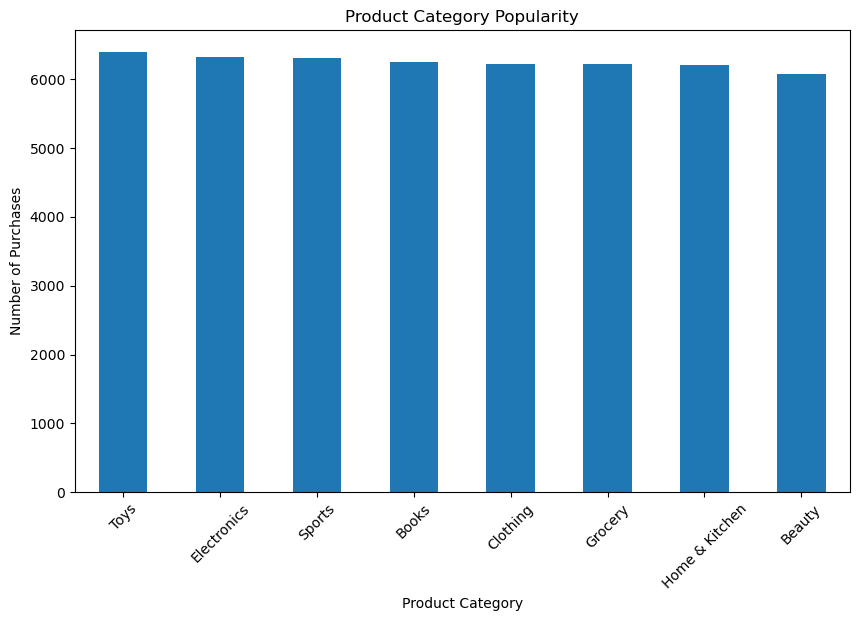

In [29]:
plt.figure(figsize=(10,6))

product_popularity.plot(kind='bar')

plt.title('Product Category Popularity')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

plt.show()

In [31]:
#--- SALES TREND ANALYSIS

#-- CHECK THE DATE RANGE
print("Start Date:", df['Transaction_Date'].min())
print("End Date:", df['Transaction_Date'].max())

Start Date: 2023-03-09 00:00:00
End Date: 2025-03-08 00:00:00


In [33]:
#-- CREATE A MONTHLY SALES COLUMN

monthly_sales = df.groupby('Age')['Purchase_Amount'].sum()

monthly_sales

Age
18    472940.84
19    488187.68
20    486045.16
21    452478.93
22    478085.70
23    477970.70
24    452609.61
25    451523.21
26    483160.09
27    497708.22
28    477770.85
29    468893.47
30    464662.79
31    473356.15
32    478372.32
33    493629.66
34    505485.30
35    438157.43
36    487032.91
37    480249.57
38    490940.23
39    474370.87
40    477310.16
41    509490.63
42    499838.59
43    485773.12
44    461356.55
45    496967.15
46    478114.93
47    440629.87
48    485249.03
49    456832.36
50    477733.35
51    481119.76
52    478485.52
53    450890.95
54    448639.83
55    461127.49
56    449941.50
57    475653.40
58    459342.00
59    516922.54
60    478442.61
61    484794.13
62    475101.73
63    473280.08
64    475513.99
65    468541.68
66    467391.28
67    469757.25
68    453170.22
69    471066.21
70    475880.05
Name: Purchase_Amount, dtype: float64

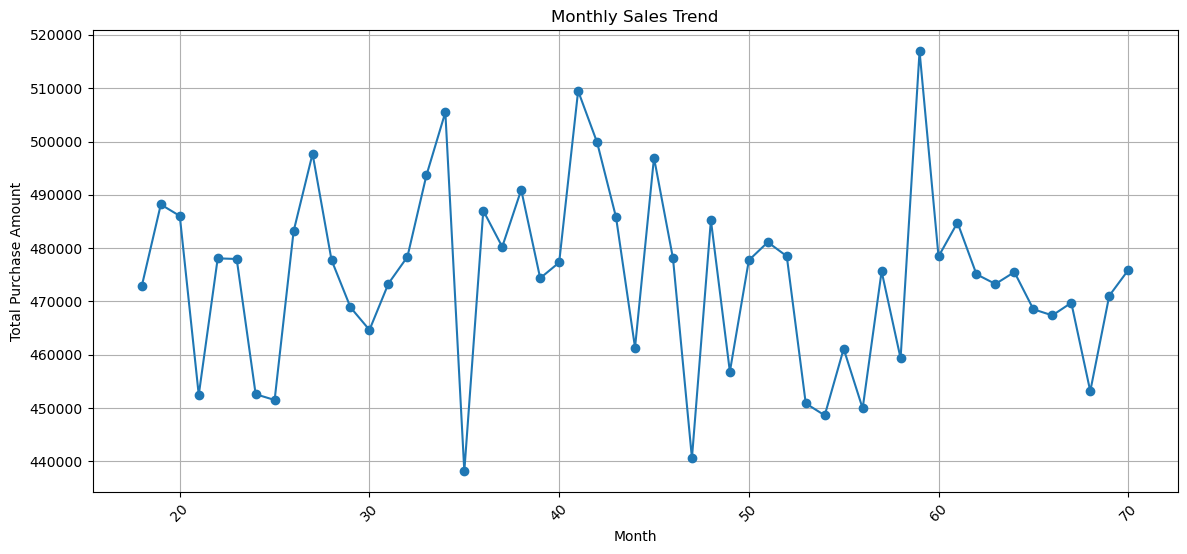

In [34]:
#--- CREATE THE MONTHLY SALES CHART

plt.figure(figsize=(14,6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [36]:
#--- FIND THE BEST SALES MONTH


#-- HIGHEST
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Best Sales Month:", best_month)
print("Sales Amount:", best_month_sales)


#--LOWEST
worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print("Lowest Sales Month:", worst_month)
print("Sales Amount:", worst_month_sales)

Best Sales Month: 59
Sales Amount: 516922.54
Lowest Sales Month: 35
Sales Amount: 438157.43


Product_Category
Sports            3195335.90
Toys              3185652.36
Books             3181897.30
Clothing          3171225.96
Electronics       3133965.04
Grocery           3123579.52
Home & Kitchen    3108945.78
Beauty            3057387.79
Name: Purchase_Amount, dtype: float64


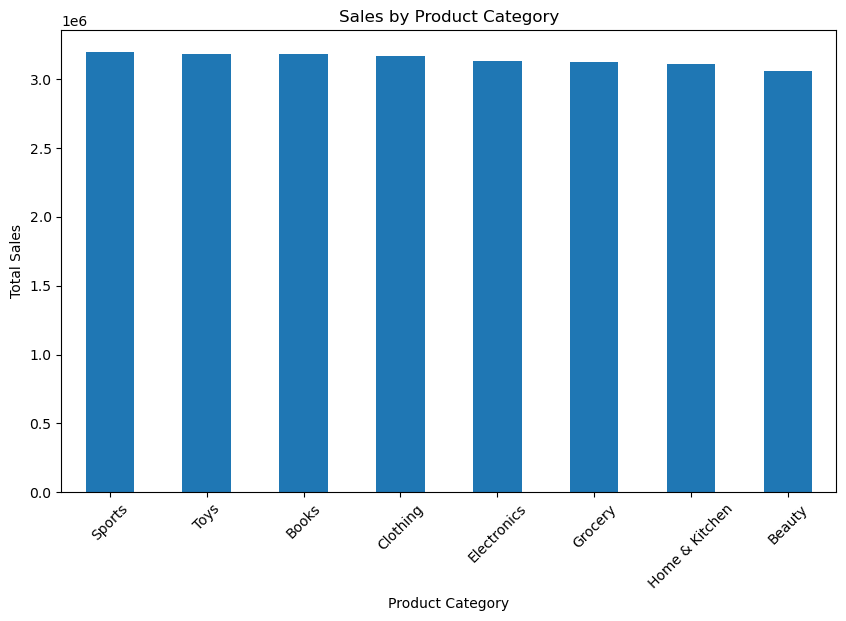

In [37]:
#-- ANALYZE SALES BY PRODUCT CATEGORY

category_sales = (
    df.groupby('Product_Category')['Purchase_Amount']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(10,6))

category_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()


Payment_Method
UPI                 8477
Cash on Delivery    8434
Debit Card          8355
Credit Card         8310
PayPal              8250
Net Banking         8174
Name: count, dtype: int64


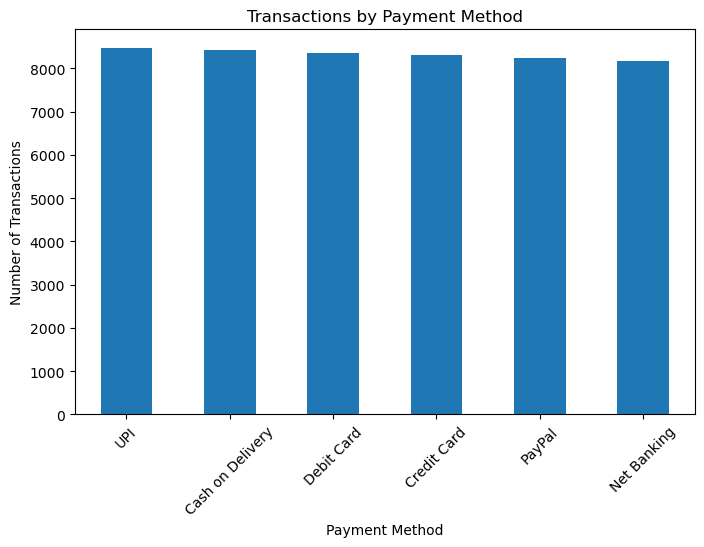

In [39]:
#--- ANALYZE PAYMENT METHODS

payment_counts = df['Payment_Method'].value_counts()

print(payment_counts)


#--CHART
plt.figure(figsize=(8,5))

payment_counts.plot(kind='bar')

plt.title('Transactions by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()

In [40]:
#--- CUSTOMER SEGMENTATION

customer_summary = df.groupby('User_Name').agg(
    Total_Spend=('Purchase_Amount', 'sum'),
    Purchase_Count=('Transaction_ID', 'count')
)

customer_summary.head()

,Total_Spend,Purchase_Count
User_Name,,
Ava Allen,247865.13,494
Ava Anderson,246801.09,491
Ava Clark,273776.79,517
Ava Hall,268756.73,517
Ava Harris,266846.08,520


In [41]:
def segment_customer(row):
    if row['Purchase_Count'] == 1:
        return 'One-time Buyer'
    elif row['Total_Spend'] >= customer_summary['Total_Spend'].quantile(0.75):
        return 'High Value'
    else:
        return 'Regular'

customer_summary['Customer_Segment'] = customer_summary.apply(
    segment_customer,
    axis=1
)

In [42]:
customer_summary.head(10)

,Total_Spend,Purchase_Count,Customer_Segment
User_Name,,,
Ava Allen,247865.13,494,Regular
Ava Anderson,246801.09,491,Regular
Ava Clark,273776.79,517,High Value
Ava Hall,268756.73,517,High Value
Ava Harris,266846.08,520,High Value
Ava Lewis,250501.42,493,Regular
Ava Rodriguez,266860.12,514,High Value
Ava Thompson,245798.83,500,Regular
Ava Walker,263862.78,517,High Value


In [43]:
#---COUNT EACH CUSTOMER SEGEMNET


segment_counts = customer_summary['Customer_Segment'].value_counts()

print(segment_counts)

Customer_Segment
Regular       75
High Value    25
Name: count, dtype: int64


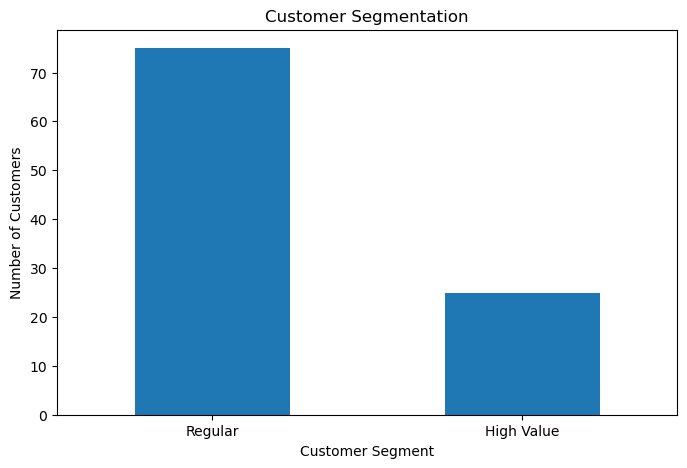

In [44]:
plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [46]:
#-- TOP 10% CUSTOMER AND REVENUE CONTRIBUTION


#--SORT CUSTOMER BY SPENDING
customer_summary = customer_summary.sort_values(
    by='Total_Spend',
    ascending=False
)

customer_summary.head(10)

,Total_Spend,Purchase_Count,Customer_Segment
User_Name,,,
Sophia Harris,296354.98,568,High Value
James Allen,278079.15,545,High Value
Olivia Hall,277302.09,534,High Value
Isabella Hall,275798.04,539,High Value
Noah Anderson,274347.15,545,High Value
Emma Clark,274313.60,546,High Value
Ava Clark,273776.79,517,High Value
Elijah Hall,271861.61,543,High Value
James Lewis,271007.68,543,High Value


In [47]:
# FIND TOTAL NUMBER OF CUSTOMER

total_customers = len(customer_summary)

print("Total Customers:", total_customers)

Total Customers: 100


In [48]:
#CALCULATE THE TOP 10%

top_10_count = int(total_customers * 0.10)

print("Top 10% Customer Count:", top_10_count)

Top 10% Customer Count: 10


In [49]:
## SELECT THE TOP 10% CUSTOMER

top_10_customers = customer_summary.head(top_10_count)

top_10_customers.head()

,Total_Spend,Purchase_Count,Customer_Segment
User_Name,,,
Sophia Harris,296354.98,568,High Value
James Allen,278079.15,545,High Value
Olivia Hall,277302.09,534,High Value
Isabella Hall,275798.04,539,High Value
Noah Anderson,274347.15,545,High Value


In [50]:
# CALCULATE THEIR REVENUE

top_10_revenue = top_10_customers['Total_Spend'].sum()

total_revenue = customer_summary['Total_Spend'].sum()

print("Top 10% Customer Revenue:", top_10_revenue)
print("Total Revenue:", total_revenue)

Top 10% Customer Revenue: 2761597.8200000003
Total Revenue: 25157989.65


In [51]:
# Calculate revenue contribution %


revenue_contribution = (top_10_revenue / total_revenue) * 100

print("Top 10% Revenue Contribution:", revenue_contribution, "%")

Top 10% Revenue Contribution: 10.977021051441605 %


In [52]:
# VISUALIZE

top_10_revenue = top_10_customers['Total_Spend'].sum()

other_revenue = total_revenue - top_10_revenue

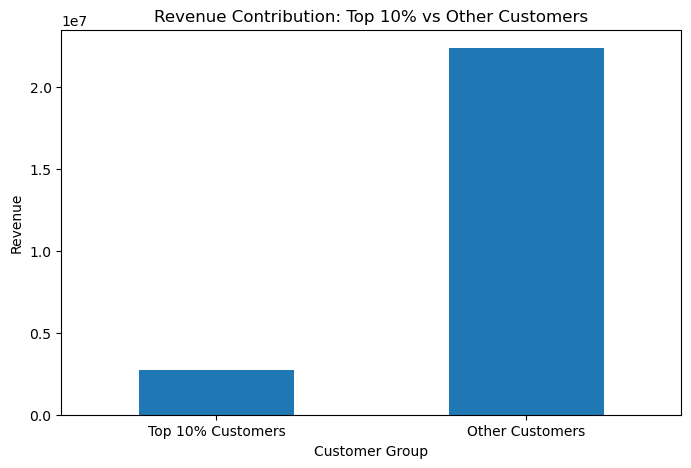

In [53]:
revenue_groups = pd.Series({
    'Top 10% Customers': top_10_revenue,
    'Other Customers': other_revenue
})

plt.figure(figsize=(8,5))

revenue_groups.plot(kind='bar')

plt.title('Revenue Contribution: Top 10% vs Other Customers')
plt.xlabel('Customer Group')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.show()

In [54]:
# CUSTOMER SEGEMENT REVENUE


segment_revenue = (
    customer_summary
    .groupby('Customer_Segment')['Total_Spend']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Customer_Segment
Regular       18437665.23
High Value     6720324.42
Name: Total_Spend, dtype: float64


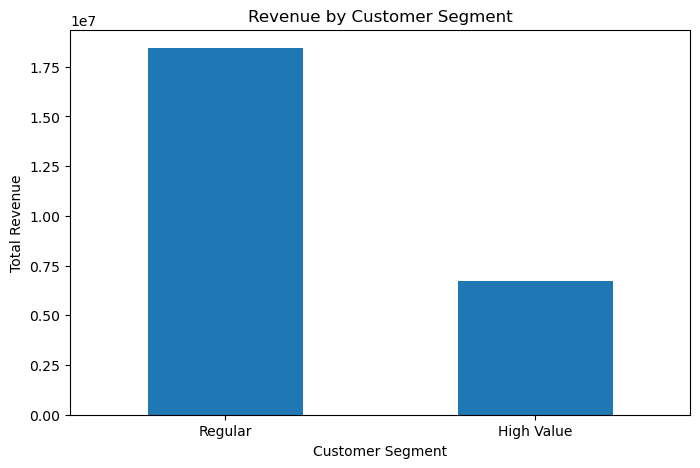

In [55]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

In [57]:
#FINAL CUSTOMER ANALYSIS


customer_analysis = customer_summary.copy()

customer_analysis['Average_Spend_Per_Purchase'] = (
    customer_analysis['Total_Spend'] /
    customer_analysis['Purchase_Count']
)

customer_analysis.head(10)

#--HIGHEST VALUE
customer_analysis.sort_values(
    by='Total_Spend',
    ascending=False
).head(10)

,Total_Spend,Purchase_Count,Customer_Segment,Average_Spend_Per_Purchase
User_Name,,,,
Sophia Harris,296354.98,568,High Value,521.751725
James Allen,278079.15,545,High Value,510.236972
Olivia Hall,277302.09,534,High Value,519.292303
Isabella Hall,275798.04,539,High Value,511.684675
Noah Anderson,274347.15,545,High Value,503.389266
Emma Clark,274313.60,546,High Value,502.405861
Ava Clark,273776.79,517,High Value,529.548917
Elijah Hall,271861.61,543,High Value,500.665948
James Lewis,271007.68,543,High Value,499.093333


In [58]:
# TOTAL REVENUE 
print("Total Revenue:", df['Purchase_Amount'].sum())

Total Revenue: 25157989.65


In [59]:
# TOTAL TRANSACTIONS
print("Total Transactions:", df['Transaction_ID'].nunique())

Total Transactions: 50000


In [60]:
#NUMBER OF CUSTOMER

print("Total Customers:", df['User_Name'].nunique())

Total Customers: 100


In [61]:
#AVERAGE PURCHASE

print("Average Purchase:", df['Purchase_Amount'].mean())


Average Purchase: 503.159793


In [62]:
# BEST SELLING CATEGORY BY REVENUE

print("Best Product Category:")
print(category_sales.idxmax())
print("Revenue:", category_sales.max())

Best Product Category:
Sports
Revenue: 3195335.9


In [63]:
# BEST SALES MONTH


print("Best Sales Month:", monthly_sales.idxmax())
print("Revenue:", monthly_sales.max())

Best Sales Month: 59
Revenue: 516922.54


In [64]:
# TOP 10% REVENUE CONTRIBUTION

print("Top 10% Revenue Contribution:",
      round(revenue_contribution, 2), "%")

Top 10% Revenue Contribution: 10.98 %


In [65]:
# CUSTOMER SEGMENTS

print(segment_counts)

Customer_Segment
Regular       75
High Value    25
Name: count, dtype: int64


In [66]:
#-- FINAL SUMMARY TABLE

final_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Transactions',
        'Total Customers',
        'Average Purchase Amount',
        'Best Product Category',
        'Best Sales Month',
        'Top 10% Revenue Contribution'
    ],
    
    'Value': [
        round(df['Purchase_Amount'].sum(), 2),
        df['Transaction_ID'].nunique(),
        df['User_Name'].nunique(),
        round(df['Purchase_Amount'].mean(), 2),
        category_sales.idxmax(),
        str(monthly_sales.idxmax()),
        round(revenue_contribution, 2)
    ]
})

final_summary

,Metric,Value
0,Total Revenue,25157989.65
1,Total Transactions,50000
2,Total Customers,100
3,Average Purchase Amount,503.16
4,Best Product Category,Sports
5,Best Sales Month,59
6,Top 10% Revenue Contribution,10.98


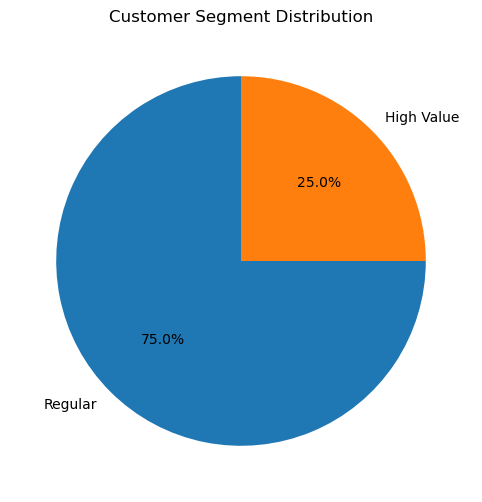

In [67]:
#-- FINAL CUSTOMER SEGMENTATION CHART

plt.figure(figsize=(8,6))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Segment Distribution')

plt.show()

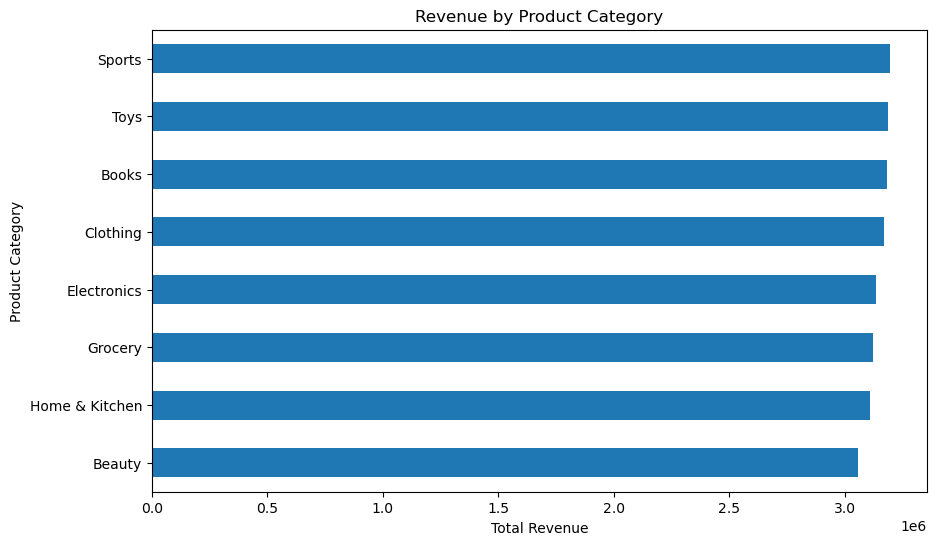

In [68]:
#-- PRODUCT CATEGORY REVENUE CHART


plt.figure(figsize=(10,6))

category_sales.sort_values().plot(kind='barh')

plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')

plt.show()

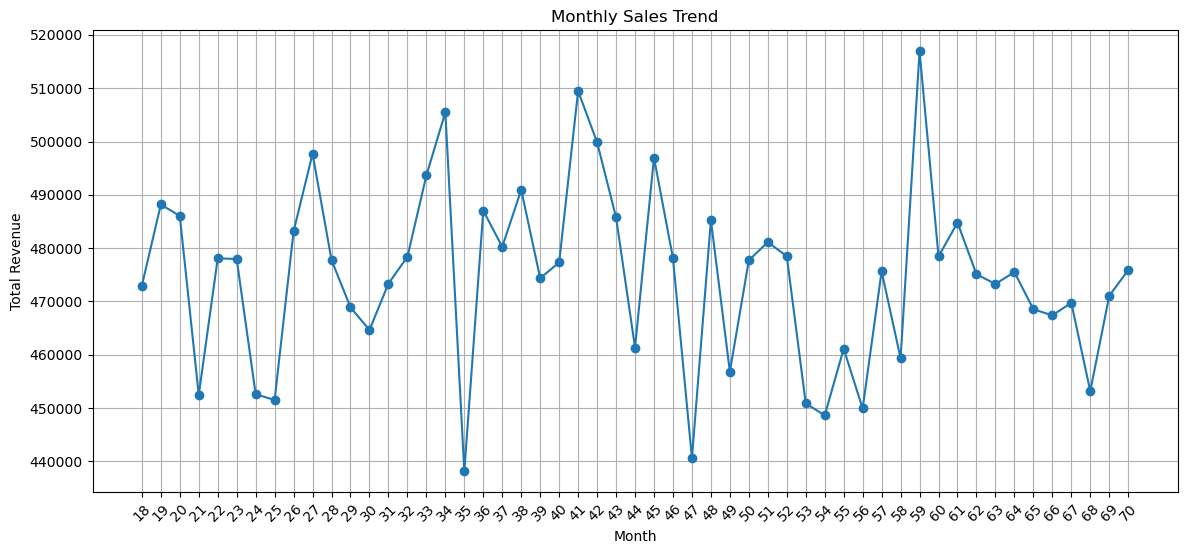

In [69]:
# MONTHLY SALES TREND

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [70]:
#-- SAVE THE CLEANED DATASET

df.to_csv(
    'cleaned_ecommerce_transactions.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
